In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [34]:
df = pd.read_excel("../data/raw/flood dataset.xlsx")

In [35]:
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [36]:
df.tail()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
110,28,71,30,3035.1,66.2,313.5,2209.1,446.3,262.833333,664.3,0
111,29,71,37,2151.1,18.3,287.4,1535.6,309.8,143.433333,335.0,0
112,30,74,42,3255.4,43.9,218.5,2561.2,431.8,347.566667,923.4,1
113,31,71,31,3046.4,14.9,364.5,2164.8,502.1,151.466667,203.4,0
114,28,71,34,2600.6,8.9,465.9,1514.7,611.1,187.866667,361.8,0


In [37]:
df.shape

(115, 11)

In [38]:
df.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='str')

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [40]:
df.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [41]:
df.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [42]:
df.duplicated().sum()

np.int64(0)

Exploratory Analysis

In [43]:
df['flood'].value_counts()

flood
0    99
1    16
Name: count, dtype: int64

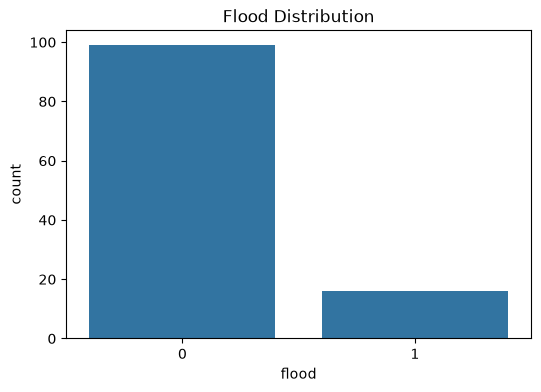

In [44]:
#countplot
plt.figure(figsize=(6,4))
sns.countplot(x='flood', data=df)
plt.title("Flood Distribution")
plt.show()

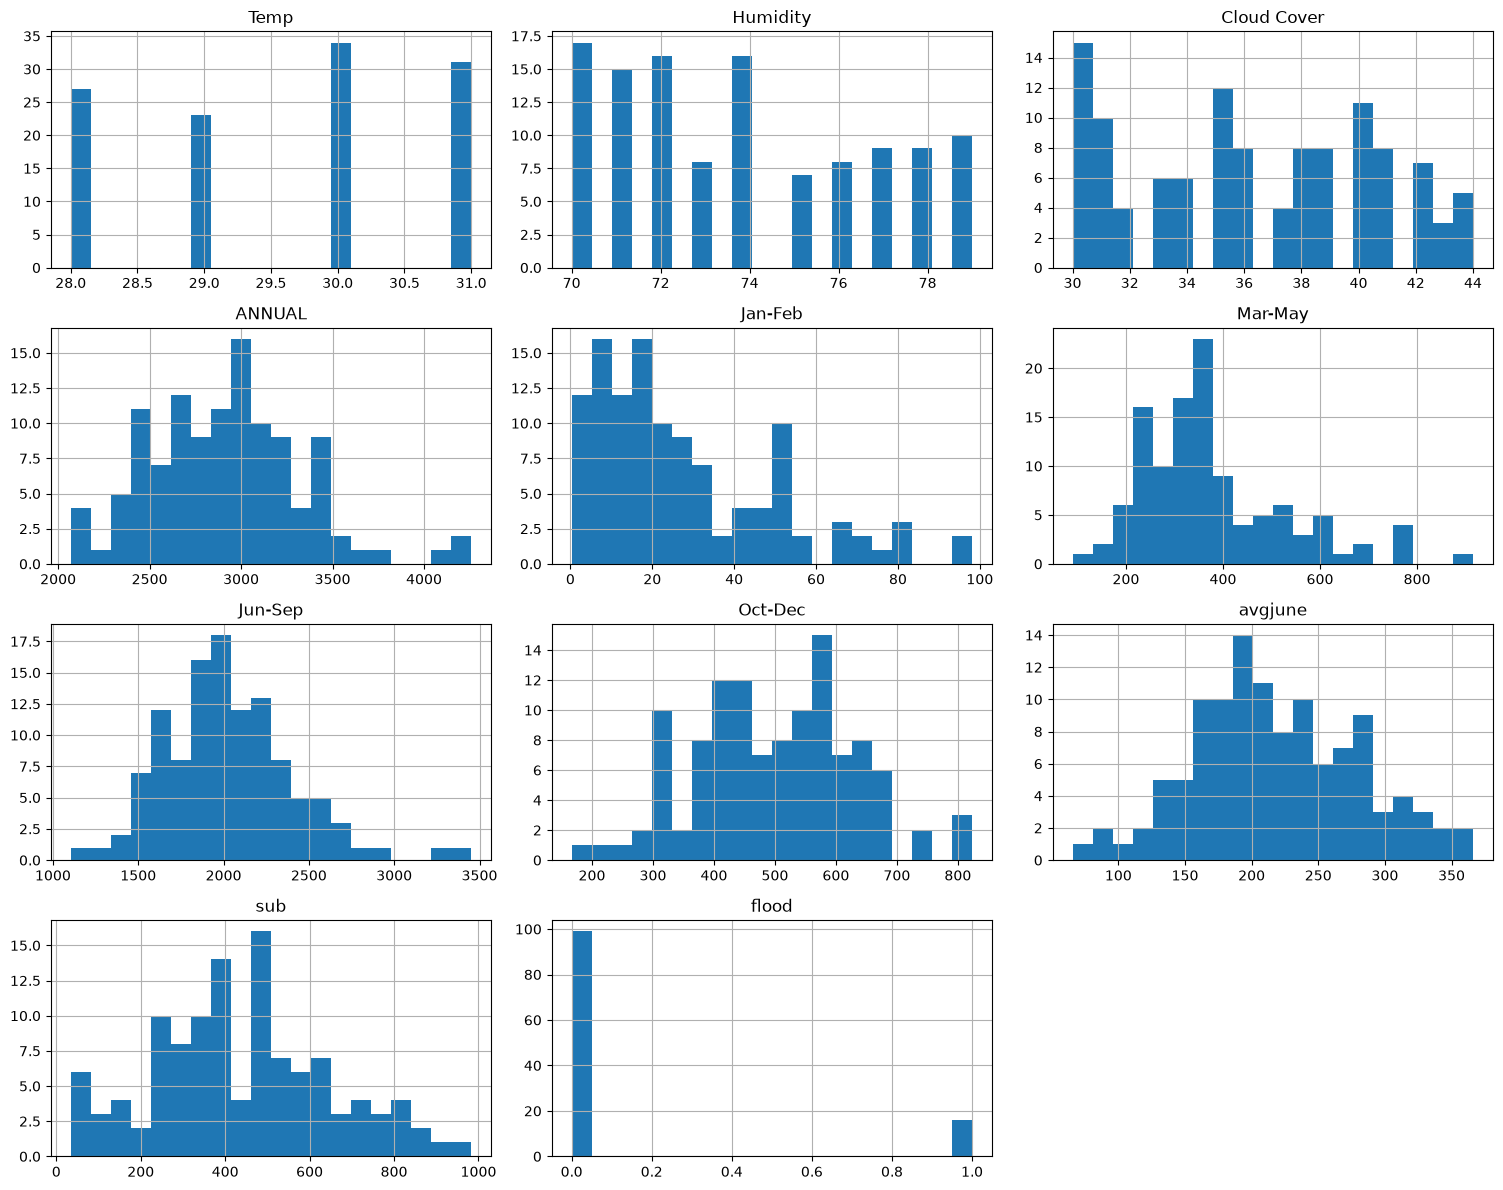

In [45]:
#histogram
df.hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

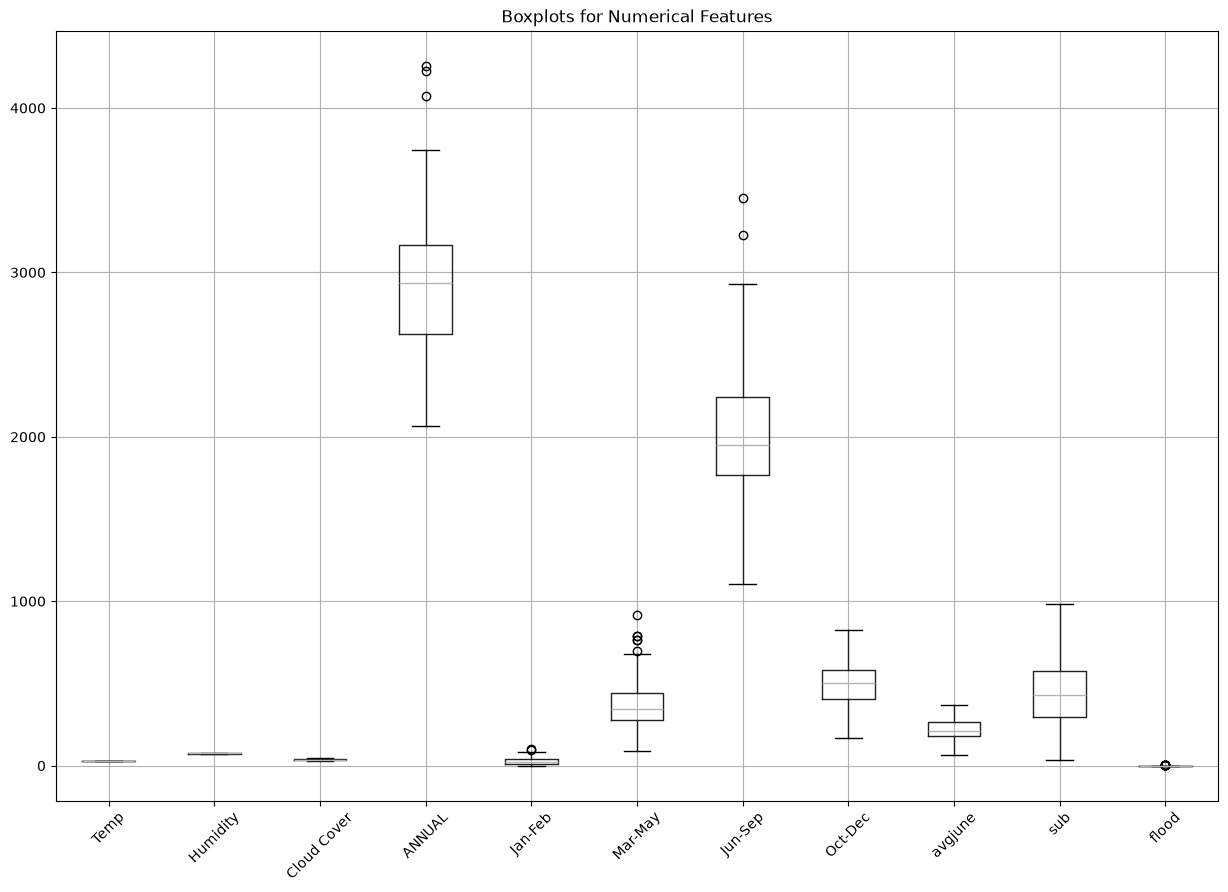

In [46]:
#boxplot
plt.figure(figsize=(15,10))
df.boxplot(rot=45)
plt.title("Boxplots for Numerical Features")
plt.show()

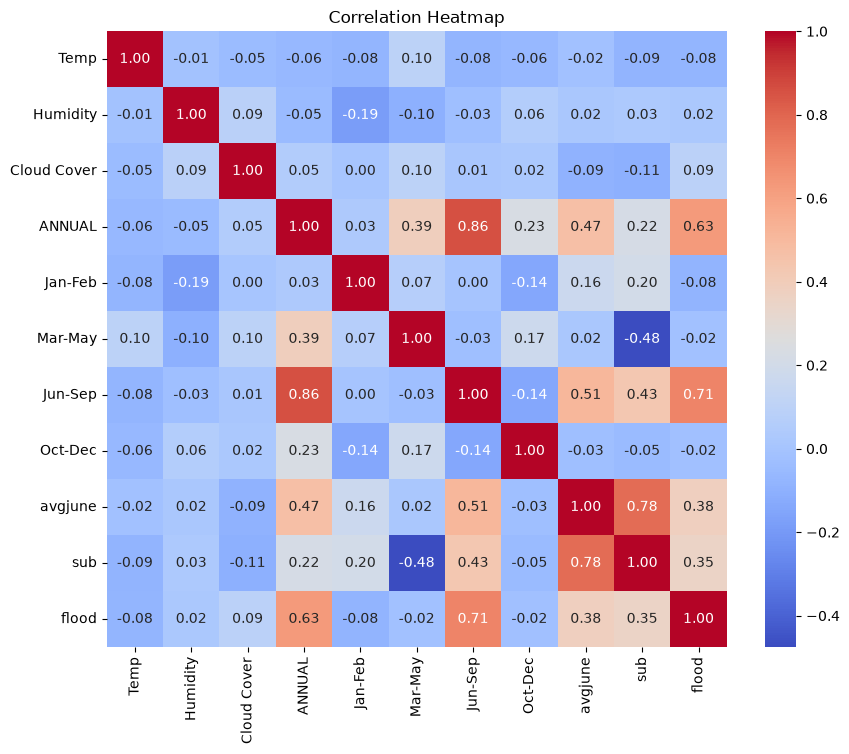

In [47]:
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

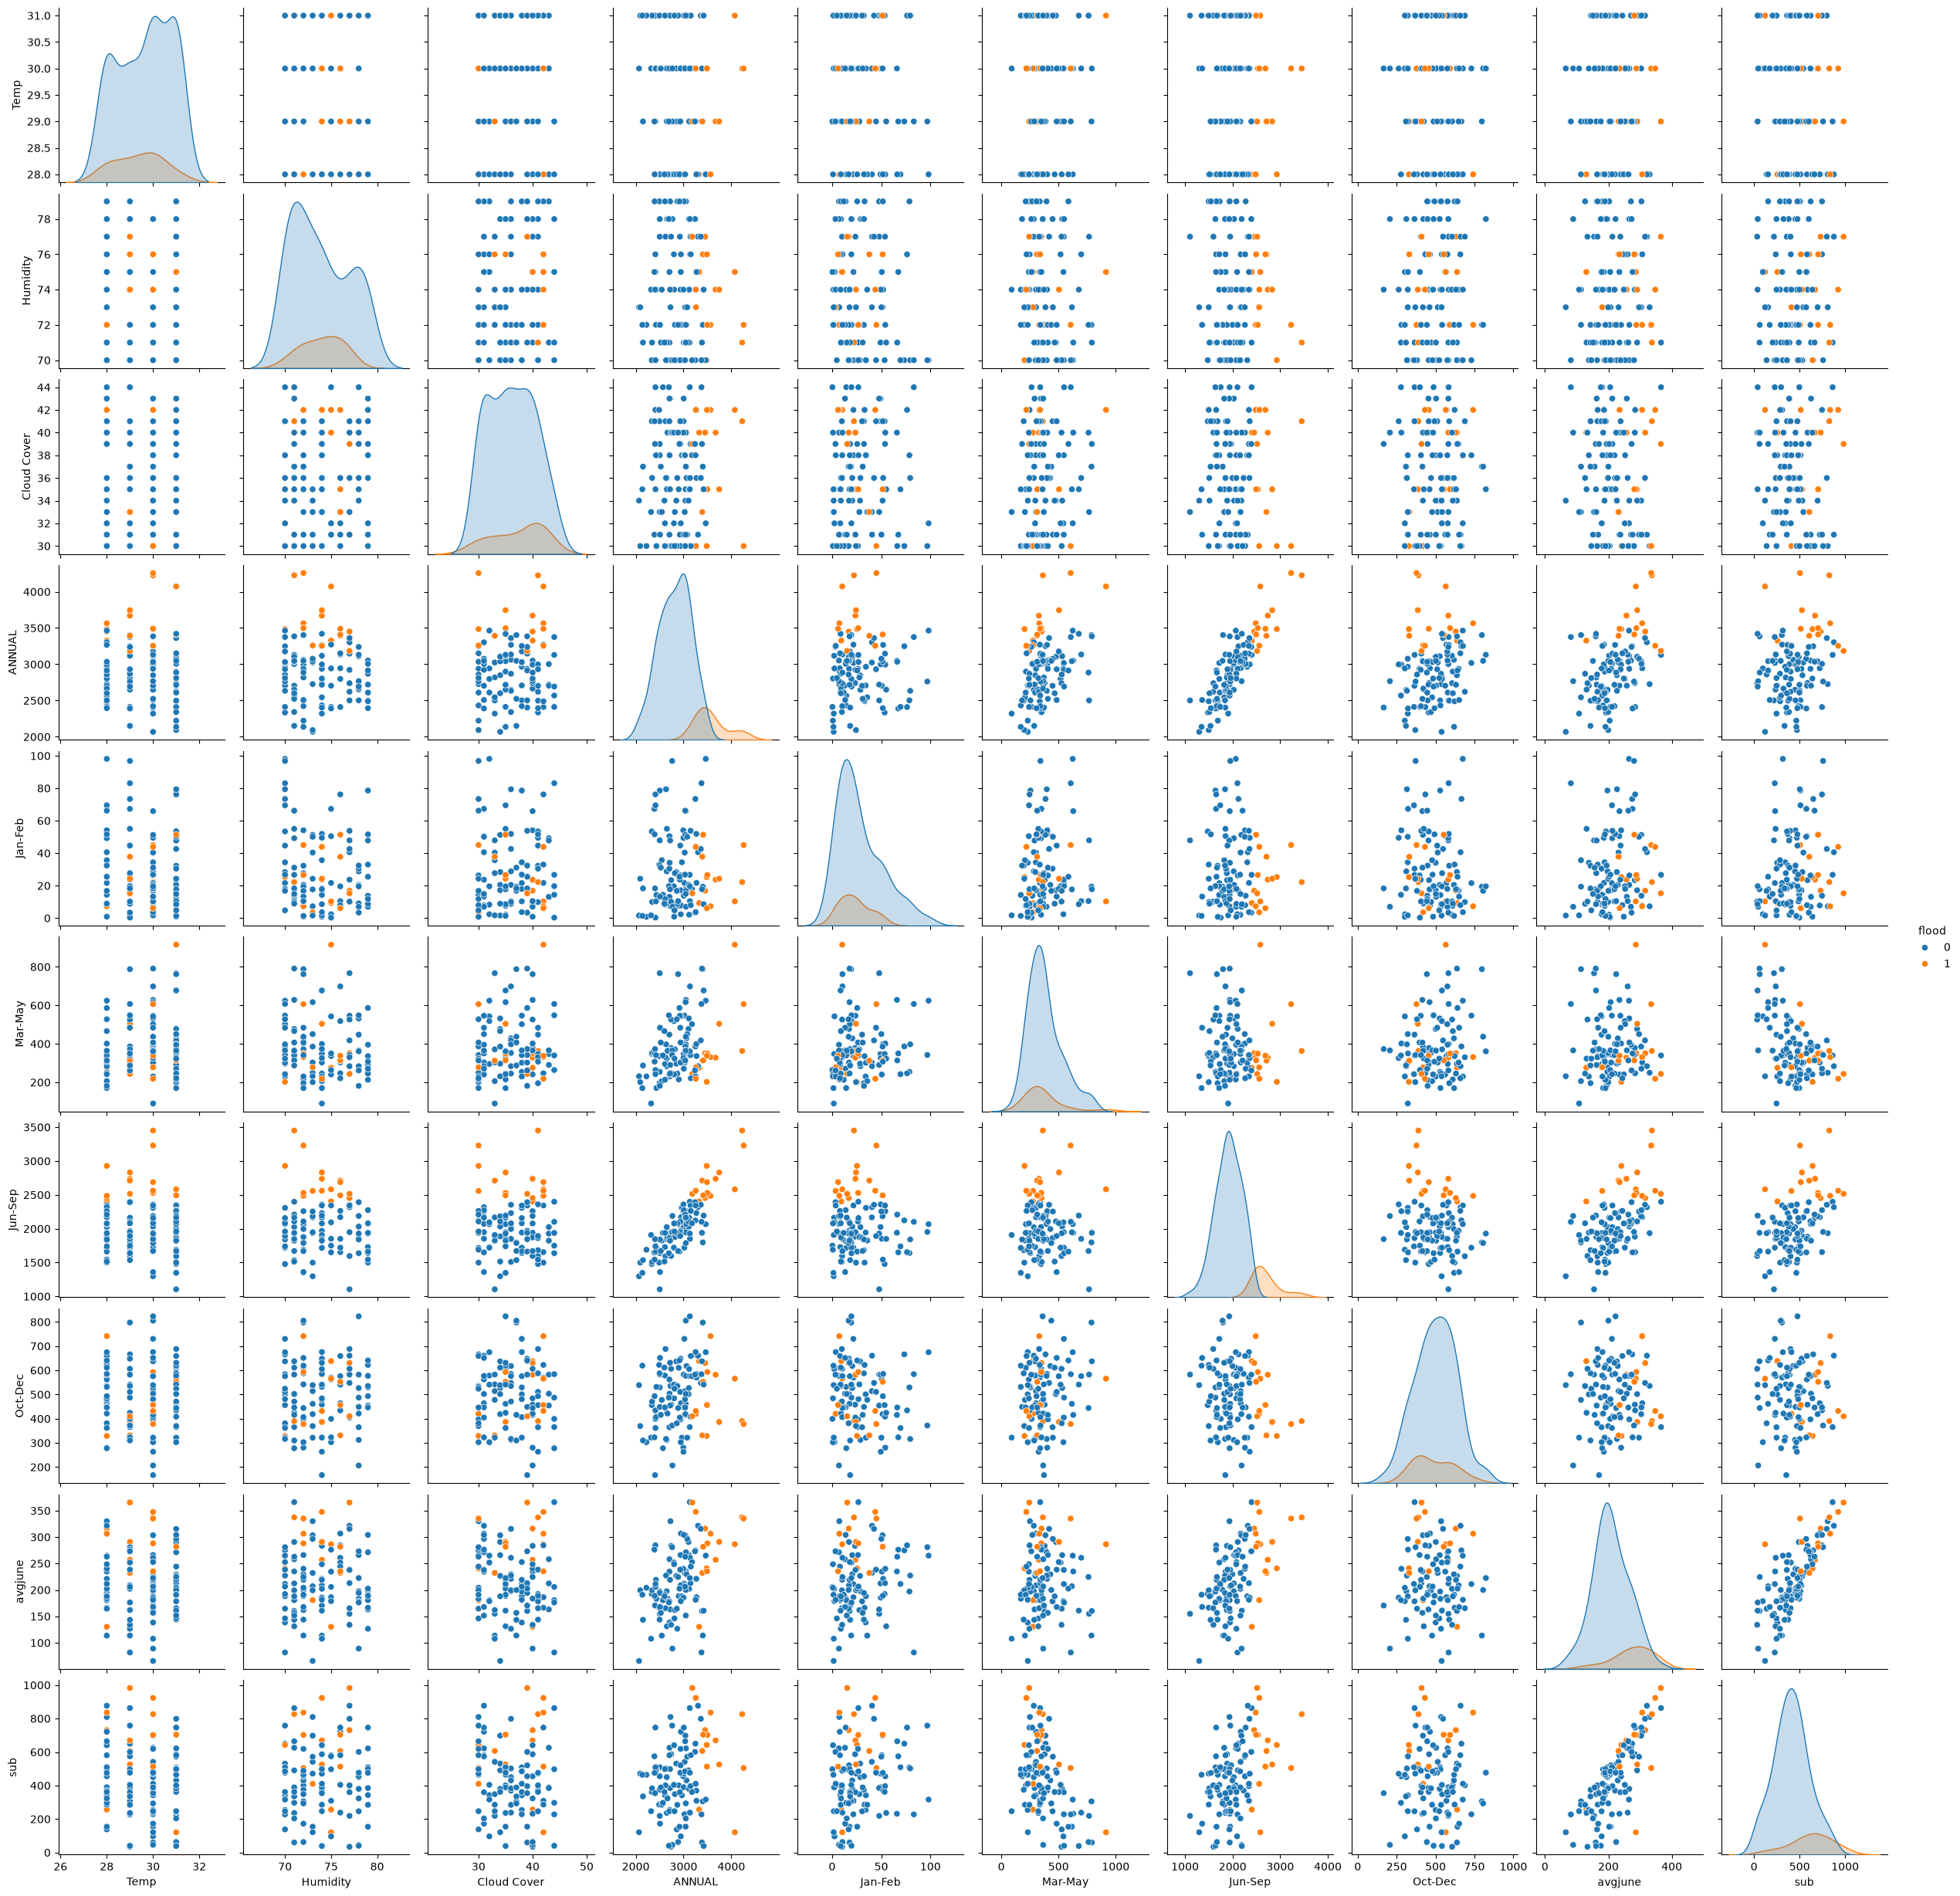

In [48]:
#pair plot
sns.pairplot(df, hue='flood')
plt.show()

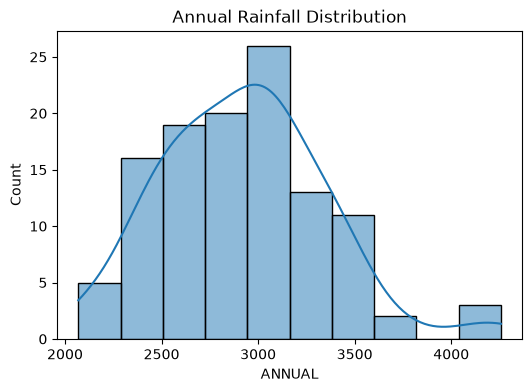

In [49]:
#distribution plot
plt.figure(figsize=(6,4))
sns.histplot(df['ANNUAL'], kde=True)
plt.title("Annual Rainfall Distribution")
plt.show()

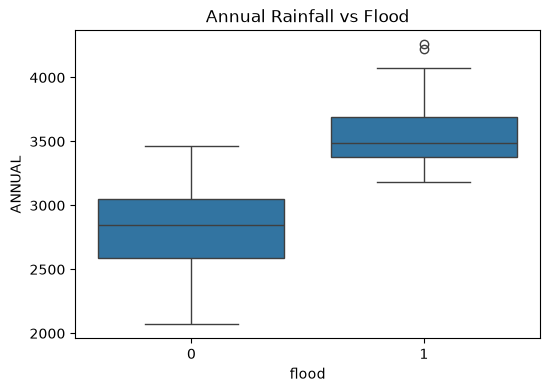

In [50]:
plt.figure(figsize=(6,4))
sns.boxplot(x='flood', y='ANNUAL', data=df)
plt.title("Annual Rainfall vs Flood")
plt.show()

Data Preprocessing

In [51]:
#separate features 
X = df.drop("flood", axis=1)

y = df["flood"]

In [52]:
print(X.shape)
print(y.shape)

(115, 10)
(115,)


In [53]:
#train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
import joblib

joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [56]:
print(X_train_scaled[:5])

[[ 1.18780995  1.3123629   1.14227916 -0.53320538  0.14848678  0.44288851
  -0.45944179 -0.95169783 -0.75996069 -0.95518953]
 [ 0.29936674 -1.36325786  0.44168127 -0.52257097  0.315421   -0.97471146
  -0.24055714  0.09472634 -1.45475609 -0.91644675]
 [ 0.29936674  1.3123629  -0.25891661  0.47895446 -0.35695294 -0.1223282
  -0.28066828  2.57249283  0.00292927  0.17619753]
 [-1.47751969  0.64345771 -1.19304712  0.0382171  -0.90412622 -0.49675171
   0.36270383 -0.18877624  1.46119171  1.374281  ]
 [ 1.18780995  0.64345771 -0.25891661  1.13828809  1.11763266 -0.42837872
   1.22017912  0.49193728  1.02723312  1.2884584 ]]


model building

model 1: Decision tree

In [57]:
#importing libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [58]:
#create model
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [59]:
#train model
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [60]:
#make predictions
y_pred_dt = dt_model.predict(X_test)

In [61]:
#accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9565217391304348


In [62]:
#precision
dt_precision = precision_score(y_test, y_pred_dt)

print("Precision:", dt_precision)

Precision: 1.0


In [63]:
#recall
dt_recall = recall_score(y_test, y_pred_dt)

print("Recall:", dt_recall)

Recall: 0.6666666666666666


In [64]:
#f1 score
dt_f1 = f1_score(y_test, y_pred_dt)

print("F1 Score:", dt_f1)

F1 Score: 0.8


In [65]:
#confustion matrix
cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[20  0]
 [ 1  2]]


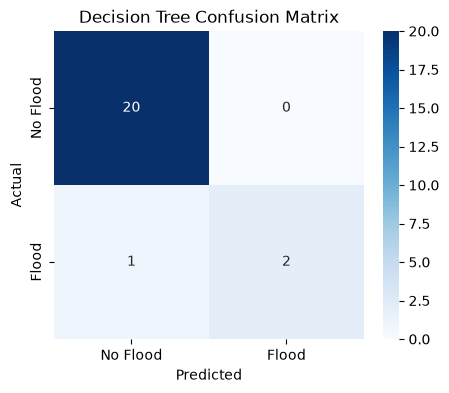

In [66]:
#plotting confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Flood","Flood"],
    yticklabels=["No Flood","Flood"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [72]:
#classification report 
print(classification_report(y_test, y_pred_dt))
report = classification_report(
    y_test,
    y_pred_dt
)

print(report)

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



In [73]:
#feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

       Feature  Importance
6      Jun-Sep         1.0
0         Temp         0.0
1     Humidity         0.0
2  Cloud Cover         0.0
4      Jan-Feb         0.0
3       ANNUAL         0.0
5      Mar-May         0.0
7      Oct-Dec         0.0
8      avgjune         0.0
9          sub         0.0


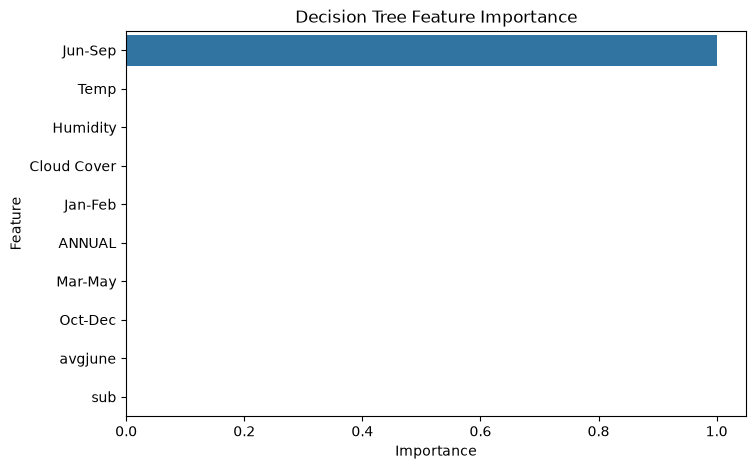

In [74]:
#plotting
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Decision Tree Feature Importance")

plt.show()

In [75]:
#summary table 
model_results = []

In [76]:
model_results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1
})

model 2: Random forest

In [77]:
#import libray
from sklearn.ensemble import RandomForestClassifier

In [78]:
#create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [79]:
#train model
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [80]:
#predict
y_pred_rf = rf_model.predict(X_test)

Random Forest Accuracy: 0.9565217391304348
Precision: 1.0
Recall: 0.6666666666666666
F1 Score: 0.8
[[20  0]
 [ 1  2]]


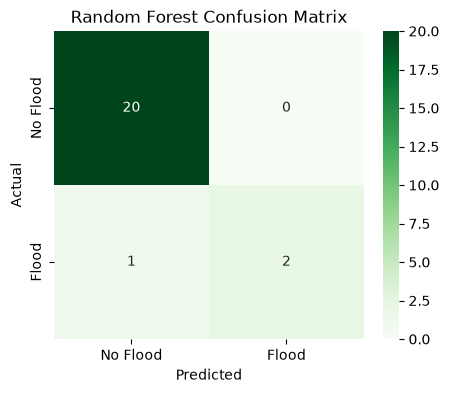

In [81]:
#accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

#precision
rf_precision = precision_score(y_test, y_pred_rf)

print("Precision:", rf_precision)

#recall
rf_recall = recall_score(y_test, y_pred_rf)

print("Recall:", rf_recall)

#f1 score
rf_f1 = f1_score(y_test, y_pred_rf)

print("F1 Score:", rf_f1)

#confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

#plot confusion matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Flood","Flood"],
    yticklabels=["No Flood","Flood"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [82]:
#classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



       Feature  Importance
6      Jun-Sep    0.520786
3       ANNUAL    0.235143
9          sub    0.075681
8      avgjune    0.061186
2  Cloud Cover    0.026077
5      Mar-May    0.025531
7      Oct-Dec    0.024455
4      Jan-Feb    0.015674
1     Humidity    0.007934
0         Temp    0.007533


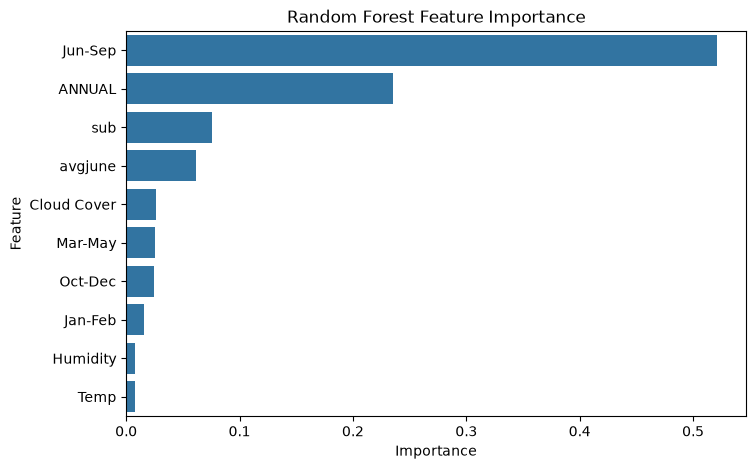

In [84]:
#feature importance
feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_rf)


#plotting 
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_rf
)

plt.title("Random Forest Feature Importance")

plt.show()

In [86]:
model_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
})

model 3: KNN

In [87]:
#import 
from sklearn.neighbors import KNeighborsClassifier

In [88]:
#create model
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [89]:
#train model
knn_model.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [90]:
#prediction 
y_pred_knn = knn_model.predict(
    X_test_scaled
)

KNN Accuracy: 0.8695652173913043
Precision: 0.5
Recall: 0.3333333333333333
F1 Score: 0.4
[[19  1]
 [ 2  1]]


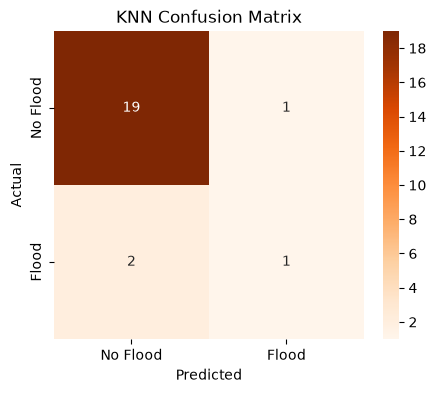

In [91]:
#accuracy
knn_accuracy = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", knn_accuracy)

#precision
knn_precision = precision_score(
    y_test,
    y_pred_knn
)

print("Precision:", knn_precision)

#recall
knn_recall = recall_score(
    y_test,
    y_pred_knn
)

print("Recall:", knn_recall)

#f1 score
knn_f1 = f1_score(
    y_test,
    y_pred_knn
)

print("F1 Score:", knn_f1)

#confusion matrix
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print(cm_knn)

#plot confusion matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Flood","Flood"],
    yticklabels=["No Flood","Flood"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("KNN Confusion Matrix")

plt.show()


In [93]:
#classification report
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

#save reuslts
model_results.append({
    "Model": "KNN",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall": knn_recall,
    "F1 Score": knn_f1
})

              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.50      0.33      0.40         3

    accuracy                           0.87        23
   macro avg       0.70      0.64      0.66        23
weighted avg       0.85      0.87      0.86        23



model 4:xg boost

In [95]:
#import
from xgboost import XGBClassifier

In [96]:
#create model
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [97]:
#train mkodel
xgb_model.fit(X_train, y_train)

C:\Users\Gowthami\OneDrive\Documents\MYPROJECTS\RisingWatersProject\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:07:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [98]:
#prediction
y_pred_xgb = xgb_model.predict(X_test)

XGBoost Accuracy: 0.8695652173913043
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
[[20  0]
 [ 3  0]]


C:\Users\Gowthami\OneDrive\Documents\MYPROJECTS\RisingWatersProject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


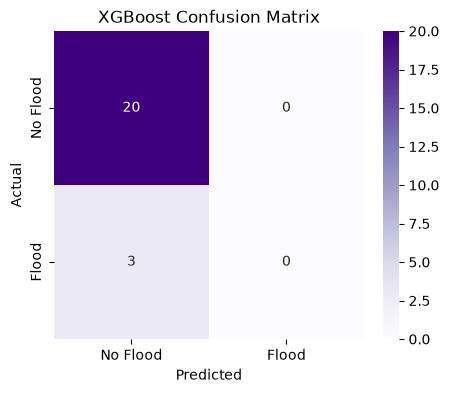

In [99]:
#accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

#precision
xgb_precision = precision_score(y_test, y_pred_xgb)

print("Precision:", xgb_precision)


#recall
xgb_recall = recall_score(y_test, y_pred_xgb)

print("Recall:", xgb_recall)


#f1 score
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("F1 Score:", xgb_f1)


#confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

#plot 
plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No Flood","Flood"],
    yticklabels=["No Flood","Flood"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()



In [100]:
#classification report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        20
           1       0.00      0.00      0.00         3

    accuracy                           0.87        23
   macro avg       0.43      0.50      0.47        23
weighted avg       0.76      0.87      0.81        23



C:\Users\Gowthami\OneDrive\Documents\MYPROJECTS\RisingWatersProject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Gowthami\OneDrive\Documents\MYPROJECTS\RisingWatersProject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Gowthami\OneDrive\Documents\MYPROJECTS\RisingWatersProject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

       Feature  Importance
6      Jun-Sep         1.0
0         Temp         0.0
1     Humidity         0.0
2  Cloud Cover         0.0
4      Jan-Feb         0.0
3       ANNUAL         0.0
5      Mar-May         0.0
7      Oct-Dec         0.0
8      avgjune         0.0
9          sub         0.0


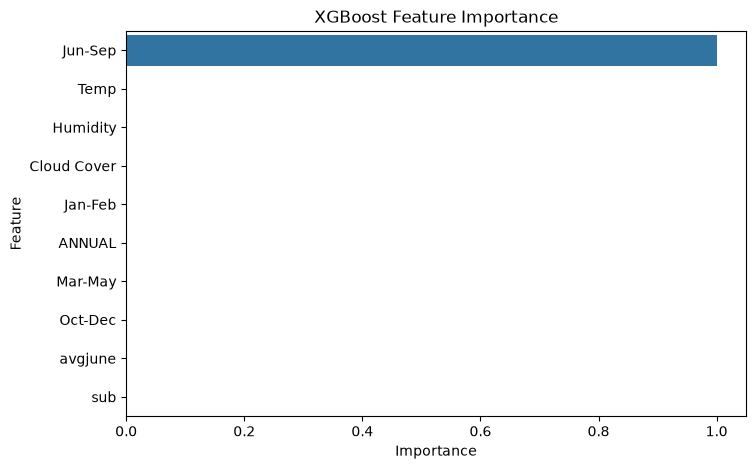

In [101]:
#feature importtance
feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_xgb)

#ploting
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_xgb
)

plt.title("XGBoost Feature Importance")

plt.show()

In [103]:
#save result 
model_results.append({
    "Model":"XGBoost",
    "Accuracy":xgb_accuracy,
    "Precision":xgb_precision,
    "Recall":xgb_recall,
    "F1 Score":xgb_f1
})

In [104]:
results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.956522,1.0,0.666667,0.8
1,Random Forest,0.956522,1.0,0.666667,0.8
2,Random Forest,0.956522,1.0,0.666667,0.8
3,KNN,0.869565,0.5,0.333333,0.4
4,KNN,0.869565,0.5,0.333333,0.4
5,XGBoost,0.869565,0.0,0.000000,0.0


In [108]:
best_model = rf_model
import joblib

joblib.dump(best_model, "../models/floods.save")

['../models/floods.save']

In [109]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.956522,1.0,0.666667,0.8
1,Random Forest,0.956522,1.0,0.666667,0.8
2,Random Forest,0.956522,1.0,0.666667,0.8
3,KNN,0.869565,0.5,0.333333,0.4
4,KNN,0.869565,0.5,0.333333,0.4
5,XGBoost,0.869565,0.0,0.000000,0.0


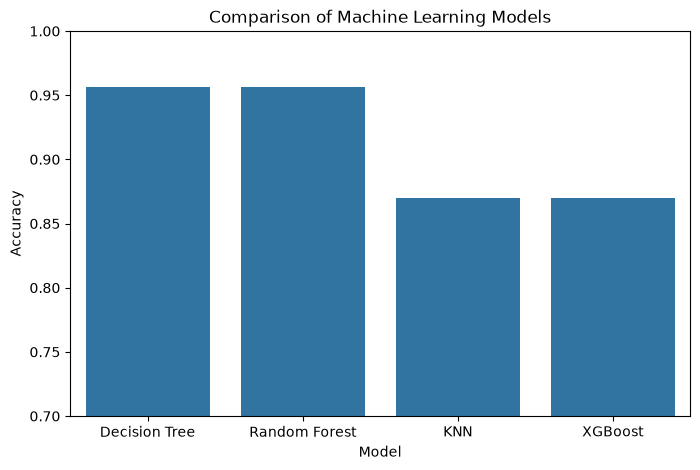

In [110]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Comparison of Machine Learning Models")

plt.ylim(0.7,1.0)

plt.show()

In [111]:
loaded_model = joblib.load("../models/floods.save")

prediction = loaded_model.predict(X_test)

print(prediction[:10])

[0 0 0 0 0 0 0 0 0 0]


In [112]:
print("Actual Values:")
print(y_test.values[:10])

print("\nPredicted Values:")
print(prediction[:10])

Actual Values:
[0 0 0 0 0 0 0 0 1 0]

Predicted Values:
[0 0 0 0 0 0 0 0 0 0]


In [113]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": prediction
})

comparison.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,1,0
9,0,0


In [114]:
prediction_original = rf_model.predict(X_test)
prediction_loaded = loaded_model.predict(X_test)

print("Are both predictions identical?",
      (prediction_original == prediction_loaded).all())

Are both predictions identical? True


In [115]:
from sklearn.metrics import accuracy_score

loaded_accuracy = accuracy_score(y_test, prediction_loaded)

print("Loaded Model Accuracy:", loaded_accuracy)

Loaded Model Accuracy: 0.9565217391304348


In [116]:
results_df.to_csv("../models/model_comparison.csv", index=False)